In [9]:
import os, json
import numpy as np
import pandas as pd

import joblib
import matplotlib.pyplot as plt

OUT_DIR = "../outputs/stage2/"
os.makedirs(OUT_DIR, exist_ok=True)

with open("../outputs/preprocess/feature_names.json", "r", encoding="utf-8") as f:
    FEATURE_NAMES = json.load(f)
RANDOM_STATE = 42


In [10]:
def feature_to_group(fname: str) -> str:
    """Map a *final preprocessed feature name* to one of 5 semantic groups.
    Groups are intentionally coarse to be ZK-friendly in Stage 3.
    """
    # 1) Protocol one-hot
    if fname.startswith("proto_"):
        return "Protocol"

    # 2) Ports (numeric)
    if fname in {"src_port", "dst_port"}:
        return "Ports"

    # 3) Connection state one-hot
    if fname.startswith("conn_state_"):
        return "ConnectionState"

    # 4) Traffic volume / intensity
    if (
        any(key in fname for key in ["_bytes", "_pkts"])
        or fname in {"duration", "missed_bytes", "http_request_body_len", "http_response_body_len"}
    ):
        return "TrafficVolume"

    # 5) Application / service level (HTTP/TLS/DNS/Weird + service)
    if (
        fname.startswith("service_")
        or fname.startswith("http_")
        or fname.startswith("ssl_")
        or fname.startswith("dns_")
        or fname.startswith("weird_")
        or fname in {"http_trans_depth"}
    ):
        return "Application"

    # Fallback: keep within the 5 groups (avoid "Other" for Stage 3)
    return "Application"

# quick sanity
test_examples = ["proto_tcp", "dst_port", "dst_bytes", "conn_state_REJ", "ssl_version_NONE", "weird_name_NONE"]
for ex in test_examples:
    print(ex, "->", feature_to_group(ex))


proto_tcp -> Protocol
dst_port -> Ports
dst_bytes -> TrafficVolume
conn_state_REJ -> ConnectionState
ssl_version_NONE -> Application
weird_name_NONE -> Application


In [11]:
topk_xgb = np.load("../outputs/stage2/topk_xgb.npy")
topk_logreg = np.load("../outputs/stage2/topk_logreg.npy")


def topk_to_group_sets(topk_idx, feature_names):
    group_sets = []
    for row in topk_idx:
        groups = [feature_to_group(feature_names[i]) for i in row]
        group_sets.append(set(groups))
    return group_sets

group_sets_xgb = topk_to_group_sets(topk_xgb, FEATURE_NAMES)
group_sets_logreg = topk_to_group_sets(topk_logreg, FEATURE_NAMES)

print("Example group set (XGB):", list(group_sets_xgb)[0])
print("Example group set (LogReg):", list(group_sets_logreg)[0])


Example group set (XGB): {'TrafficVolume', 'ConnectionState', 'Ports', 'Protocol'}
Example group set (LogReg): {'Application', 'ConnectionState', 'Protocol'}


In [12]:
from collections import Counter

def group_frequency(group_sets):
    c = Counter()
    n = len(group_sets)
    for gs in group_sets:
        for g in gs:
            c[g] += 1
    df_out = pd.DataFrame({
        "group": list(c.keys()),
        "freq_count": list(c.values())
    })
    df_out["freq_pct"] = (df_out["freq_count"] / n * 100).round(2)
    df_out = df_out.sort_values("freq_count", ascending=False).reset_index(drop=True)
    return df_out

freq_groups_xgb = group_frequency(group_sets_xgb)
freq_groups_logreg = group_frequency(group_sets_logreg)

display(freq_groups_xgb)
display(freq_groups_logreg)

freq_groups_xgb.to_csv(os.path.join(OUT_DIR, "semantic_group_frequency_xgb.csv"), index=False)
freq_groups_logreg.to_csv(os.path.join(OUT_DIR, "semantic_group_frequency_logreg.csv"), index=False)


,group,freq_count,freq_pct
0,TrafficVolume,1095,99.55
1,Ports,1055,95.91
2,Protocol,823,74.82
3,ConnectionState,733,66.64
4,Application,77,7.00


,group,freq_count,freq_pct
0,Application,1100,100.00
1,Protocol,1099,99.91
2,ConnectionState,501,45.55
3,Ports,70,6.36
4,TrafficVolume,68,6.18


In [13]:
GROUPS = ["Protocol", "Application", "ConnectionState", "Ports", "TrafficVolume"]
GROUP_TO_ID = {g: i+1 for i, g in enumerate(GROUPS)}

# group_id per feature index (same order as FEATURE_NAMES)
group_ids = [GROUP_TO_ID[feature_to_group(f)] for f in FEATURE_NAMES]

# Export artifacts for Stage 3
art_dir = "../stage3_zk/artifacts"
os.makedirs(art_dir, exist_ok=True)

group_map = {
    "groups": GROUPS,
    "group_to_id": GROUP_TO_ID,
    "feature_index_to_group_id": group_ids,
    "feature_index_to_group_name": [feature_to_group(f) for f in FEATURE_NAMES],
    "n_features": len(FEATURE_NAMES)
}

with open(os.path.join(art_dir, "group_map.json"), "w", encoding="utf-8") as f:
    json.dump(group_map, f, indent=2)

print("✅ Saved:", os.path.join(art_dir, "group_map.json"))
print("n_features =", len(FEATURE_NAMES), "| unique groups =", sorted(set(group_map["feature_index_to_group_name"])))


✅ Saved: ../stage3_zk/artifacts\group_map.json
n_features = 104 | unique groups = ['Application', 'ConnectionState', 'Ports', 'Protocol', 'TrafficVolume']


In [14]:
def jaccard_set(a, b):
    return len(a & b) / len(a | b)

def mean_pairwise_jaccard_sets(sets_list, max_pairs=2000, seed=42):
    rng = np.random.default_rng(seed)
    n = len(sets_list)
    if n < 2:
        return 0.0
    scores = []
    for _ in range(max_pairs):
        i, j = rng.integers(0, n), rng.integers(0, n)
        if i == j:
            continue
        scores.append(jaccard_set(sets_list[i], sets_list[j]))
    return float(np.mean(scores))

semantic_stability_xgb = mean_pairwise_jaccard_sets(group_sets_xgb, max_pairs=2000, seed=RANDOM_STATE)
semantic_stability_logreg = mean_pairwise_jaccard_sets(group_sets_logreg, max_pairs=2000, seed=RANDOM_STATE)

semantic_summary = {
    "semantic_stability_jaccard_xgb": semantic_stability_xgb,
    "semantic_stability_jaccard_logreg": semantic_stability_logreg,
}

print(semantic_summary)

with open(os.path.join(OUT_DIR, "semantic_stability_summary.json"), "w") as f:
    json.dump(semantic_summary, f, indent=2)


{'semantic_stability_jaccard_xgb': 0.7428989139515455, 'semantic_stability_jaccard_logreg': 0.779423558897243}


In [15]:
semantic_overlaps = [jaccard_set(group_sets_xgb[i], group_sets_logreg[i]) for i in range(len(group_sets_xgb))]
semantic_overlap_mean = float(np.mean(semantic_overlaps))
semantic_overlap_std  = float(np.std(semantic_overlaps))

semantic_overlap_summary = {
    "semantic_overlap_mean_jaccard_xgb_vs_logreg": semantic_overlap_mean,
    "semantic_overlap_std": semantic_overlap_std
}

print(semantic_overlap_summary)

with open(os.path.join(OUT_DIR, "semantic_overlap_summary.json"), "w") as f:
    json.dump(semantic_overlap_summary, f, indent=2)


{'semantic_overlap_mean_jaccard_xgb_vs_logreg': 0.3011969696969697, 'semantic_overlap_std': 0.14676763601256326}


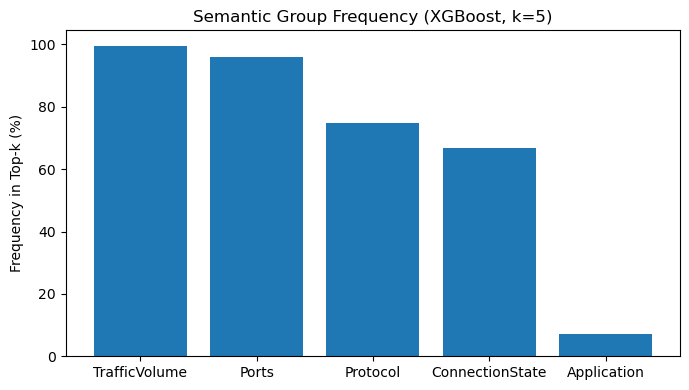

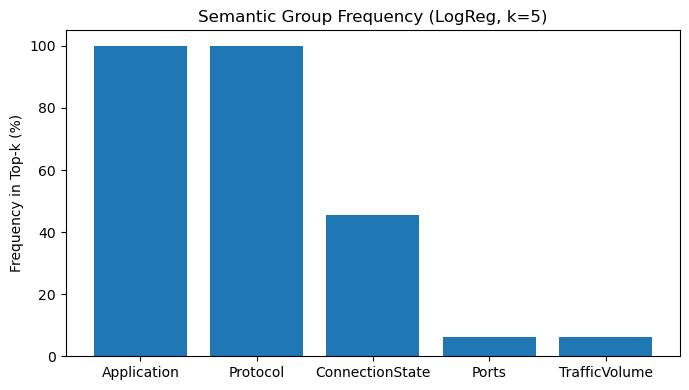

In [16]:
def plot_group_freq(df_g, title, out_path):
    plt.figure(figsize=(7, 4))
    plt.bar(df_g["group"], df_g["freq_pct"])
    plt.ylabel("Frequency in Top-k (%)")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    plt.show()

plot_group_freq(freq_groups_xgb, "Semantic Group Frequency (XGBoost, k=5)", os.path.join(OUT_DIR, "fig_semantic_groups_xgb.png"))
plot_group_freq(freq_groups_logreg, "Semantic Group Frequency (LogReg, k=5)", os.path.join(OUT_DIR, "fig_semantic_groups_logreg.png"))
